## Imports

In [1]:
%%capture
!pip install numpy pandas pyarrow tqdm onnxruntime torch tf2onnx

In [2]:
# Core Python
import os
import sys
import warnings
warnings.filterwarnings("ignore")

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Utils
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import HistGradientBoostingRegressor

# Tensorflow Utils
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    TensorBoard
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.losses import (
    BinaryCrossentropy,
    CategoricalCrossentropy,
    MeanSquaredError
)

# Onnx Conversions
import tf2onnx

## Load Dataset

In [6]:
## Download
!curl -L https://files.wundernn.io/wnn_predictorium_starterpack.tar.gz | tar -xz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0 1483M    0  164k    0     0   346k      0  1:13:03 --:--:--  1:13:03  346ktar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.FinderInfo'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring 

In [7]:
train = pd.read_parquet('/content/competition_package/datasets/train.parquet')
valid = pd.read_parquet('/content/competition_package/datasets/valid.parquet')

In [8]:
# Prep features

feature_cols = [
    c for c in train.columns
    if c not in ["seq_ix", "step_in_seq",
                 "need_prediction", "t0", "t1"]
]

print("Number of features:", len(feature_cols))

for col in feature_cols + ["t0", "t1"]:
    train[col] = train[col].astype("float32")
    valid[col] = valid[col].astype("float32")

Number of features: 32


In [ ]:
# # Sample data
# def sample_sequences(df, n_sequences, seed=42):
#     np.random.seed(seed)

#     unique_seqs = df["seq_ix"].unique()
#     sampled_seqs = np.random.choice(unique_seqs,
#                                      size=n_sequences,
#                                      replace=False)

#     return df[df["seq_ix"].isin(sampled_seqs)].copy()

# train = sample_sequences(train, n_sequences=200)
# valid = sample_sequences(test, n_sequences=100)

## EDA

In [ ]:
## Structure Check
display(train.shape)
display(train.head())
display(train.info())
display(train.describe())
test.head()

(10721000, 37)

,seq_ix,step_in_seq,need_prediction,p0,p1,p2,p3,p4,p5,p6,...,dp0,dp1,dp2,dp3,dv0,dv1,dv2,dv3,t0,t1
0,0,0,0,1.077446,-0.710366,0.373591,0.835558,0.050204,-0.139710,1.367384,...,-0.031078,-0.053527,-0.475214,-0.410787,0.805692,0.516635,-0.368215,-0.503497,-0.564226,1.864018
1,0,1,0,1.100140,-0.562796,0.483658,0.875354,0.138444,-0.010037,1.354714,...,0.950145,-0.083598,-0.604252,-0.703991,-1.925171,1.252957,-1.563974,-1.929990,-0.239079,2.168843
2,0,2,0,1.100140,-0.562796,0.483658,0.875354,0.138444,-0.010037,1.870266,...,-0.168259,1.632066,-0.178565,0.121240,1.377339,1.803970,-0.402838,1.042579,2.237778,2.459723
3,0,3,0,0.955471,-1.486537,0.230353,0.676854,-0.262686,-0.366873,2.011996,...,-0.426942,-0.743530,0.680013,1.394857,0.785266,1.424660,1.258192,0.914074,1.998699,2.272444
4,0,4,0,1.025123,-0.832006,0.317650,0.759677,-0.062770,-0.230353,2.174650,...,0.195700,0.293986,0.494971,0.267884,-1.315502,1.775372,1.302424,1.355667,1.998699,2.324245


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10721000 entries, 0 to 10720999
Data columns (total 37 columns):
 #   Column           Dtype  
---  ------           -----  
 0   seq_ix           int64  
 1   step_in_seq      int64  
 2   need_prediction  int8   
 3   p0               float64
 4   p1               float64
 5   p2               float64
 6   p3               float64
 7   p4               float64
 8   p5               float64
 9   p6               float64
 10  p7               float64
 11  p8               float64
 12  p9               float64
 13  p10              float64
 14  p11              float64
 15  v0               float64
 16  v1               float64
 17  v2               float64
 18  v3               float64
 19  v4               float64
 20  v5               float64
 21  v6               float64
 22  v7               float64
 23  v8               float64
 24  v9               float64
 25  v10              float64
 26  v11              float64
 27  dp0       

None

,seq_ix,step_in_seq,need_prediction,p0,p1,p2,p3,p4,p5,p6,...,dp0,dp1,dp2,dp3,dv0,dv1,dv2,dv3,t0,t1
count,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,...,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07,1.072100e+07
mean,5.360000e+03,4.995000e+02,9.010000e-01,1.406910e+00,-1.210059e+00,4.081931e-01,8.513727e-01,-1.252726e-01,-2.773504e-01,1.524261e+00,...,1.360129e-02,-8.331481e-02,1.342347e-01,-6.546184e-02,-2.485630e-01,4.986747e-01,9.317593e-02,-3.397429e-01,-1.662297e-01,-5.598812e-02
std,3.094886e+03,2.886750e+02,2.986620e-01,4.601623e-01,5.517048e-01,1.567414e-01,2.362825e-01,2.834494e-01,2.435492e-01,4.377065e-01,...,1.127798e+00,9.587646e-01,9.474122e-01,9.302200e-01,9.905516e-01,8.823766e-01,8.152566e-01,1.058391e+00,8.570684e-01,1.127213e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,5.630160e-01,-5.199338e+00,-3.303641e+00,-3.176243e+00,-5.199338e+00,-5.199338e+00,6.699961e-01,...,-5.199338e+00,-5.199338e+00,-5.199338e+00,-5.199338e+00,-5.199338e+00,-5.199338e+00,-5.199338e+00,-5.199338e+00,-3.439378e+01,-5.565436e+01
25%,2.680000e+03,2.497500e+02,1.000000e+00,1.025123e+00,-1.525529e+00,3.176496e-01,7.270122e-01,-1.982585e-01,-3.521514e-01,1.218002e+00,...,-6.671782e-01,-7.249732e-01,-5.932789e-01,-6.675830e-01,-9.495473e-01,-1.638238e-01,-3.955639e-01,-1.089397e+00,-6.311681e-01,-5.387243e-01
50%,5.360000e+03,4.995000e+02,1.000000e+00,1.299272e+00,-1.192071e+00,3.735909e-01,8.063648e-01,-6.276963e-02,-2.316411e-01,1.365257e+00,...,4.015699e-02,-1.587398e-01,4.088051e-01,-1.283173e-01,-1.816520e-01,5.336357e-01,8.919250e-02,-1.816520e-01,-2.390788e-01,-5.487970e-02
75%,8.040000e+03,7.492500e+02,1.000000e+00,1.597698e+00,-8.320063e-01,5.049220e-01,8.847827e-01,3.128636e-02,-1.727310e-01,1.721914e+00,...,7.750452e-01,4.483604e-01,8.266977e-01,5.049732e-01,4.459191e-01,1.095177e+00,6.104835e-01,3.924920e-01,8.606838e-02,4.315373e-01
max,1.072000e+04,9.990000e+02,1.000000e+00,5.199338e+00,3.944545e+00,5.199338e+00,5.199338e+00,5.199338e+00,3.270130e+00,5.199338e+00,...,5.199338e+00,5.199338e+00,5.199338e+00,5.199338e+00,5.199338e+00,5.199338e+00,5.199338e+00,5.199338e+00,7.942821e+01,5.388353e+01


,seq_ix,step_in_seq,need_prediction,p0,p1,p2,p3,p4,p5,p6,...,dp0,dp1,dp2,dp3,dv0,dv1,dv2,dv3,t0,t1
0,0,0,0,0.892038,-0.546700,0.293986,0.728240,0.115678,-0.018820,1.803203,...,-0.030025,0.836811,0.336509,-1.254820,-0.163824,-0.163824,-0.163824,-0.163824,-0.491662,-0.031387
1,0,1,0,1.059682,-0.658043,0.404717,0.754664,0.076604,-0.077862,2.056872,...,0.610484,-0.724973,0.522099,-0.286135,-0.163824,-0.163824,-0.163824,-0.163824,-0.375888,0.065718
2,0,2,0,1.035790,-0.832006,0.330873,0.705530,-0.006273,-0.172731,2.065579,...,0.084155,-0.445919,0.658043,-0.383024,-0.163824,-0.163824,-0.163824,-0.163824,-0.375888,0.071983
3,0,3,0,1.307063,-0.853480,0.504922,0.773140,0.020074,-0.153660,2.279624,...,0.598435,-1.004131,0.832006,-0.602943,-0.163824,-0.163824,-0.163824,-0.163824,-0.375888,0.170653
4,0,4,0,1.059682,-0.658043,0.404717,0.754664,0.076604,-0.077862,1.739312,...,0.288750,-0.046436,0.555462,-0.949547,-0.163824,-0.163824,-0.163824,-0.163824,-0.187944,0.270890


In [ ]:
# Number of sequences
display(train["seq_ix"].nunique())

# Check length per sequence
display(train.groupby("seq_ix")["step_in_seq"].count().describe())

# Verify step range
train.groupby("seq_ix")["step_in_seq"].agg(["min", "max"]).head()

10721

,step_in_seq
count,10721.0
mean,1000.0
std,0.0
min,1000.0
25%,1000.0
50%,1000.0
75%,1000.0
max,1000.0


,min,max
seq_ix,,
0,0,999
1,0,999
2,0,999
3,0,999
4,0,999


In [ ]:
# Missing
train.isnull().sum().sort_values(ascending=False).head(20)

,0
seq_ix,0
step_in_seq,0
need_prediction,0
p0,0
p1,0
p2,0
p3,0
p4,0
p5,0
p6,0


In [ ]:
# Organize based on Readme.md
price_cols = [c for c in train.columns if c.startswith("p")]
volume_cols = [c for c in train.columns if c.startswith("v")]
trade_price_cols = [c for c in train.columns if c.startswith("dp")]
trade_volume_cols = [c for c in train.columns if c.startswith("dv")]
target_cols = ["t0", "t1"]

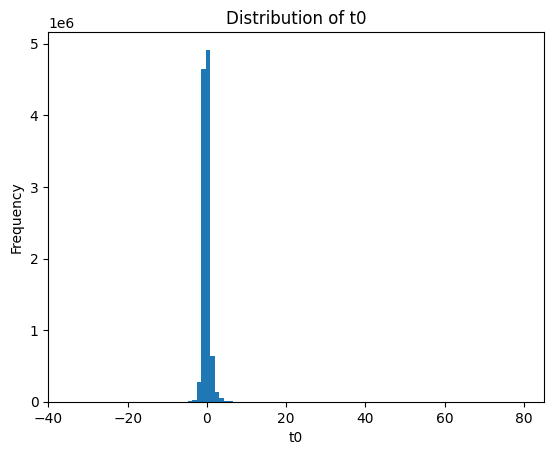

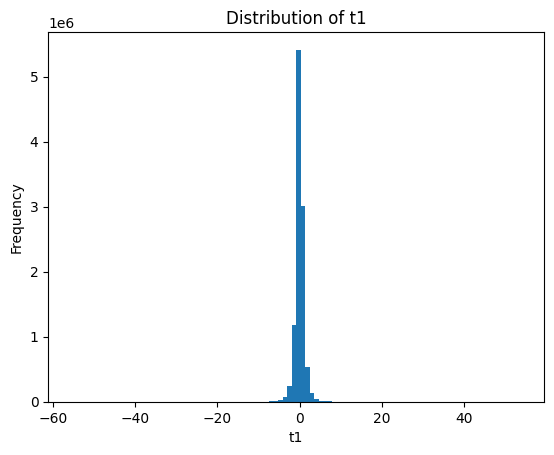

In [ ]:
# Target has extreme tails (relevant for the eval metric)
for col in target_cols:
    plt.figure()
    plt.hist(train[col].dropna(), bins=100)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


In [ ]:
for col in target_cols:
    print(col, (train[col].abs() > 6).mean())
    print(col, (train[col].abs() > 6).sum())


t0 0.0009646488200727544
t0 10342
t1 0.002806268072008208
t1 30086


In [ ]:
corr = train[price_cols + volume_cols + target_cols].corr()

# plt.figure(figsize=(10,6))
# sns.heatmap(corr.loc[target_cols, :], cmap="coolwarm", center=0)
# plt.title("Correlation of Features with Targets")
# plt.show()


KeyboardInterrupt: 

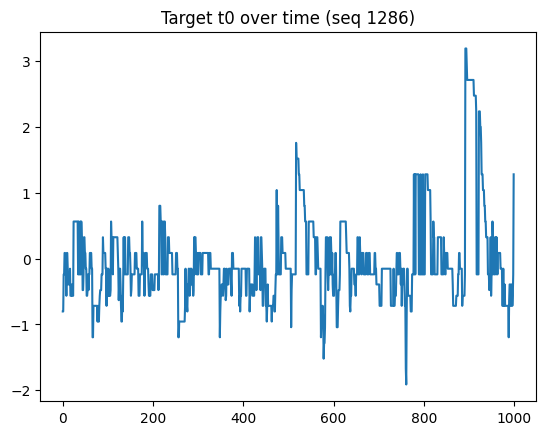

In [ ]:
seq_id = train["seq_ix"].sample(1).values[0]
seq_data = train[train["seq_ix"] == seq_id].sort_values("step_in_seq")

plt.figure()
plt.plot(seq_data["step_in_seq"], seq_data["t0"])
plt.title(f"Target t0 over time (seq {seq_id})")
plt.show()


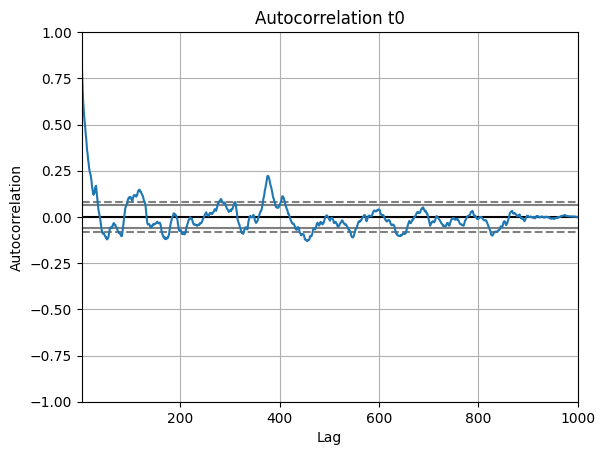

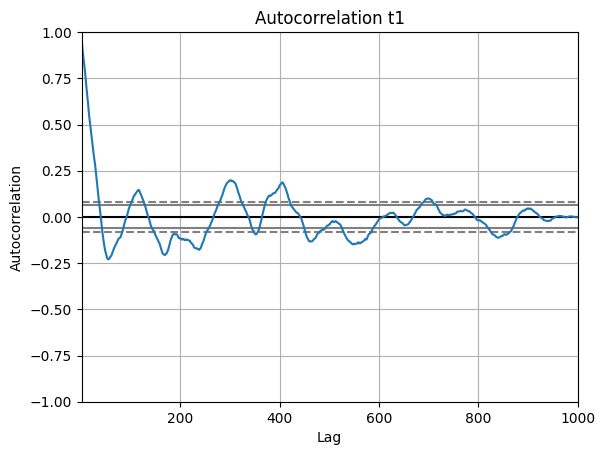

In [ ]:
from pandas.plotting import autocorrelation_plot

plt.figure()
autocorrelation_plot(seq_data["t0"])
plt.title("Autocorrelation t0")
plt.show()


plt.figure()
autocorrelation_plot(seq_data["t1"])
plt.title("Autocorrelation t1")
plt.show()

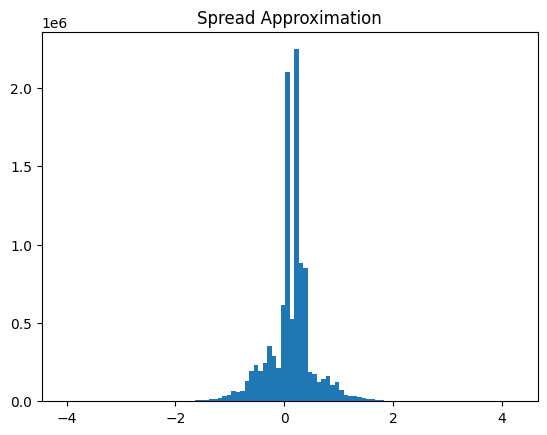

In [ ]:
train["spread_approx"] = train["p6"] - train["p0"]
plt.hist(train["spread_approx"], bins=100)
plt.title("Spread Approximation")
plt.show()


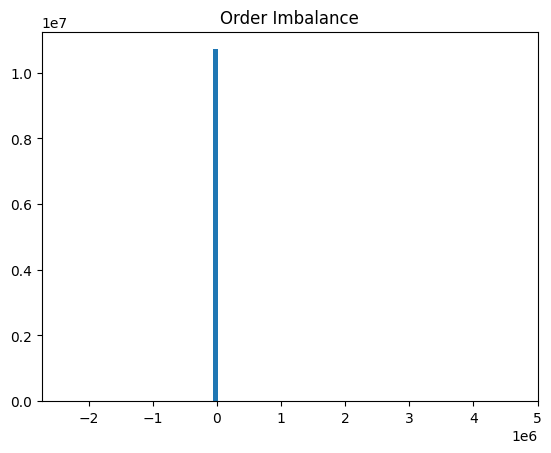

In [ ]:
train["bid_volume_sum"] = train[[f"v{i}" for i in range(6)]].sum(axis=1)
train["ask_volume_sum"] = train[[f"v{i}" for i in range(6,12)]].sum(axis=1)

train["order_imbalance"] = (
    (train["bid_volume_sum"] - train["ask_volume_sum"]) /
    (train["bid_volume_sum"] + train["ask_volume_sum"] + 1e-9)
)

plt.hist(train["order_imbalance"], bins=100)
plt.title("Order Imbalance")
plt.show()


In [ ]:
train[["order_imbalance", "t0", "t1"]].corr()

,order_imbalance,t0,t1
order_imbalance,1.000000,0.000464,0.000611
t0,0.000464,1.000000,0.505823
t1,0.000611,0.505823,1.000000


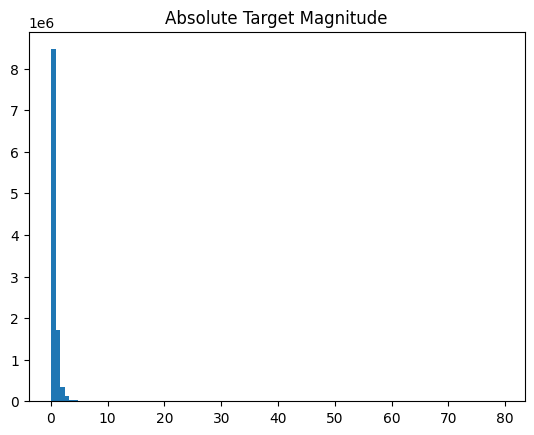

In [ ]:
train["abs_t0"] = train["t0"].abs()
train["abs_t1"] = train["t1"].abs()

plt.hist(train["abs_t0"], bins=100)
plt.title("Absolute Target Magnitude")
plt.show()

In [ ]:
high_amp = train[train["abs_t0"] > train["abs_t0"].quantile(0.9)]

high_amp.corr().loc["t0"].sort_values(ascending=False).head(10)


,t0
t0,1.000000
t1,0.699928
abs_t0,0.469698
spread_approx,0.213830
abs_t1,0.167928
p8,0.157979
p4,0.156296
p1,0.153315
v8,0.146758
dp2,0.132834


In [ ]:
high_amp = train[train["abs_t1"] > train["abs_t1"].quantile(0.9)]

high_amp.corr().loc["t1"].sort_values(ascending=False).head(10)


,t1
t1,1.000000
t0,0.562735
abs_t0,0.279037
dv2,0.058075
spread_approx,0.054930
dv3,0.053668
dp3,0.053095
v1,0.049586
v8,0.049338
dp2,0.045607


In [ ]:
# Check sequence-level target variance
seq_stats = train.groupby("seq_ix")[["t0", "t1"]].std()

seq_stats.describe()


,t0,t1
count,10721.000000,10721.000000
mean,0.786443,0.924540
std,0.324378,0.600663
min,0.275271,0.139892
25%,0.592776,0.559418
50%,0.713450,0.757111
75%,0.886331,1.095280
max,7.383015,11.946976


## Modeling

In [ ]:
def weighted_pearson(y_true, y_pred):
    # Clip predictions
    y_pred = np.clip(y_pred, -6, 6)

    weights = np.abs(y_true)

    # Weighted means
    mean_true = np.sum(weights * y_true) / np.sum(weights)
    mean_pred = np.sum(weights * y_pred) / np.sum(weights)

    # Weighted covariance
    cov = np.sum(weights * (y_true - mean_true) * (y_pred - mean_pred))

    # Weighted variances
    var_true = np.sum(weights * (y_true - mean_true)**2)
    var_pred = np.sum(weights * (y_pred - mean_pred)**2)

    return cov / np.sqrt(var_true * var_pred + 1e-12)


### Baseline - Naive Previous Values Pred

In [ ]:
df_valid = test.copy()

anchors = (
    df_valid[df_valid["step_in_seq"] == 99]
    [["seq_ix", "t0", "t1"]]
    .rename(columns={"t0": "anchor_t0",
                     "t1": "anchor_t1"})
)

df_valid = df_valid.merge(anchors, on="seq_ix", how="left")

eval_df = df_valid[df_valid["step_in_seq"] >= 99].copy()

eval_df["pred_t0"] = eval_df["anchor_t0"]
eval_df["pred_t1"] = eval_df["anchor_t1"]


score_t0 = weighted_pearson(eval_df["t0"].values,
                            eval_df["pred_t0"].values)

score_t1 = weighted_pearson(eval_df["t1"].values,
                            eval_df["pred_t1"].values)

final_score = (score_t0 + score_t1) / 2

print("t0:", score_t0)
print("t1:", score_t1)
print("Final:", final_score)


t0: 0.0020027972289865317
t1: 0.004662770936273146
Final: 0.003332784082629839


### HGBG

In [ ]:
train

,seq_ix,step_in_seq,need_prediction,p0,p1,p2,p3,p4,p5,p6,...,dp0,dp1,dp2,dp3,dv0,dv1,dv2,dv3,t0,t1
33000,33,0,0,1.425011,-0.846527,0.408938,0.895005,-0.043924,-0.312376,1.084195,...,0.288750,-0.046436,0.555462,-0.949547,-0.163824,-0.163824,-0.163824,-0.163824,-0.072171,0.283420
33001,33,1,0,1.915696,-1.693940,0.418208,0.826344,-0.361965,-0.612922,1.755869,...,-1.656224,0.445262,1.680443,1.016259,-0.656486,0.961429,0.221344,0.781626,-0.448059,0.097042
33002,33,2,0,1.931613,-1.391202,0.533154,0.895780,-0.244373,-0.486906,1.742378,...,1.818349,-0.417235,-1.270573,-1.685848,-1.346386,0.499230,-0.618059,-1.497997,-0.448059,0.095476
33003,33,3,0,1.537092,-1.563487,0.304377,0.819820,-0.052919,-0.267154,1.483249,...,-1.065801,-0.796225,-0.100041,-0.106788,0.899534,0.751333,-0.593940,-0.805692,-0.448059,-0.000063
33004,33,4,0,1.545927,-1.418119,0.357215,0.844681,0.023839,-0.198088,1.475269,...,-0.185678,-0.618059,-0.289288,-0.561469,0.199538,0.613509,-0.631785,-0.886449,-0.448059,-0.003195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10671995,10671,995,1,1.464186,-1.244778,0.462610,0.810910,-0.123259,-0.299230,1.649237,...,0.086674,0.715218,-0.788455,0.702315,0.806921,0.815212,0.537805,-1.214843,0.564226,0.256213
10671996,10671,996,1,0.975466,-1.207532,0.263985,0.699108,-0.153660,-0.316330,1.289578,...,-0.076718,0.444550,-1.239156,0.466803,-0.793955,0.974286,-0.719943,-1.198116,0.564226,0.146635
10671997,10671,997,1,0.939725,-1.926403,0.195930,0.645631,-0.373591,-0.535083,1.340200,...,-2.157446,-1.129414,1.122956,1.966244,-0.922484,2.147585,0.740342,1.908820,-0.239079,-0.323553
10671998,10671,998,1,1.554270,-0.636387,0.615025,0.907080,0.149853,0.008782,1.545927,...,1.088098,2.111363,-0.865472,-0.548188,-1.678122,-0.376408,1.391418,-2.139257,0.325147,0.035065


In [ ]:
def prepare_tabular(df):
    df = df[df["step_in_seq"] >= 99].copy()

    feature_cols = [
        c for c in df.columns
        if c not in ["seq_ix", "step_in_seq",
                     "need_prediction", "t0", "t1"]
    ]

    X = df[feature_cols]
    y0 = df["t0"]
    y1 = df["t1"]

    return X, y0, y1

X_train, y0_train, y1_train = prepare_tabular(train)
X_valid, y0_valid, y1_valid = prepare_tabular(test)

In [ ]:
model_t0 = HistGradientBoostingRegressor(
    # max_iter=300,
    # learning_rate=0.05,
    # max_depth=6,
    random_state=31
)

model_t1 = HistGradientBoostingRegressor(
    # max_iter=300,
    # learning_rate=0.05,
    # max_depth=6,
    random_state=31
)

model_t0.fit(X_train, y0_train)
model_t1.fit(X_train, y1_train)


HistGradientBoostingRegressor(random_state=31)

In [ ]:
pred_t0 = model_t0.predict(X_valid)
pred_t1 = model_t1.predict(X_valid)

In [ ]:
score_t0 = weighted_pearson(y0_valid.values, pred_t0)
score_t1 = weighted_pearson(y1_valid.values, pred_t1)

final_score = (score_t0 + score_t1) / 2

print("Validation t0:", score_t0)
print("Validation t1:", score_t1)
print("Final Score:", final_score)


Validation t0: 0.24864720413043714
Validation t1: 0.014527853708748163
Final Score: 0.13158752891959266


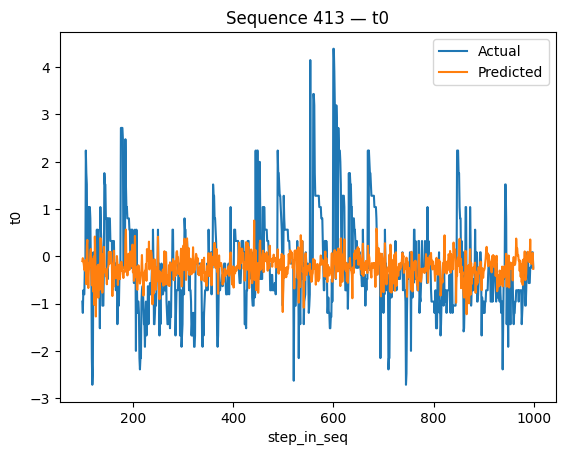

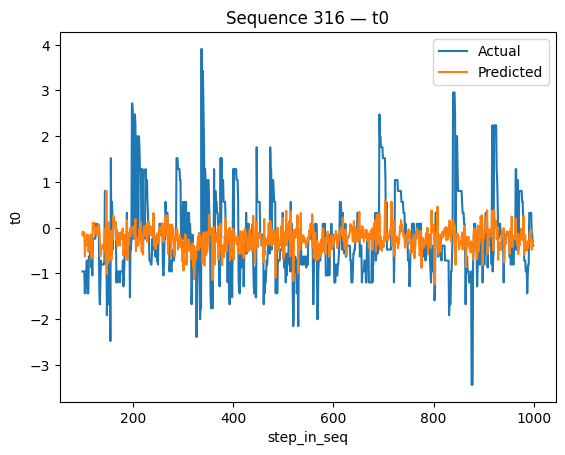

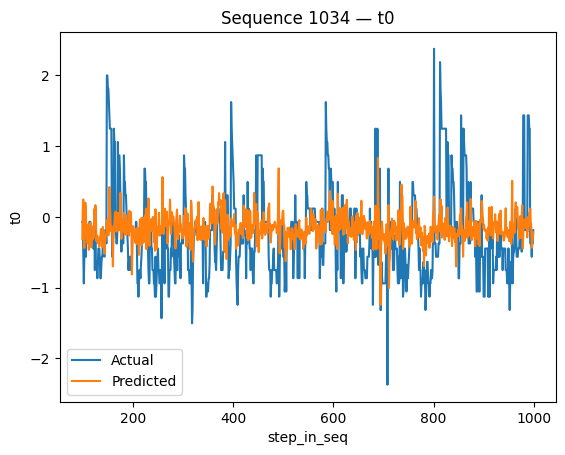

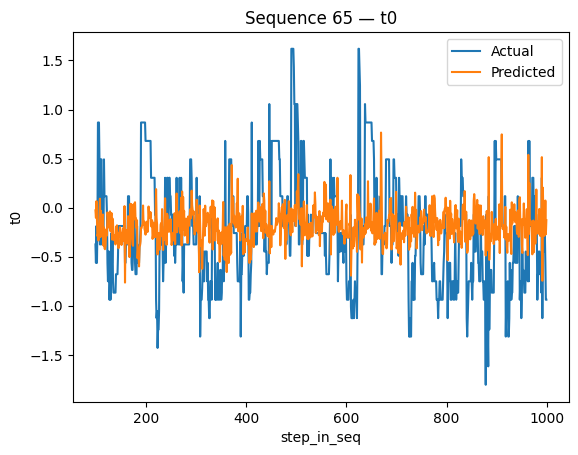

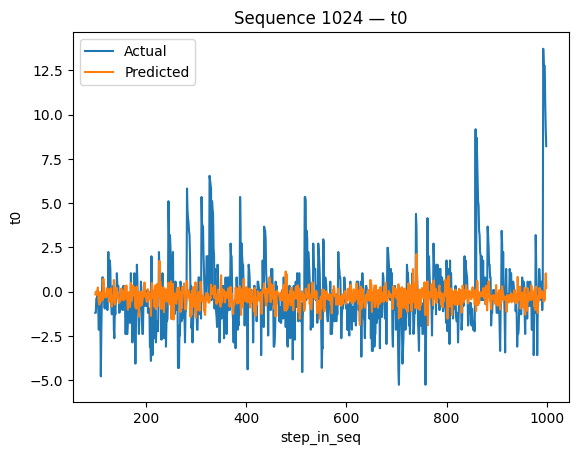

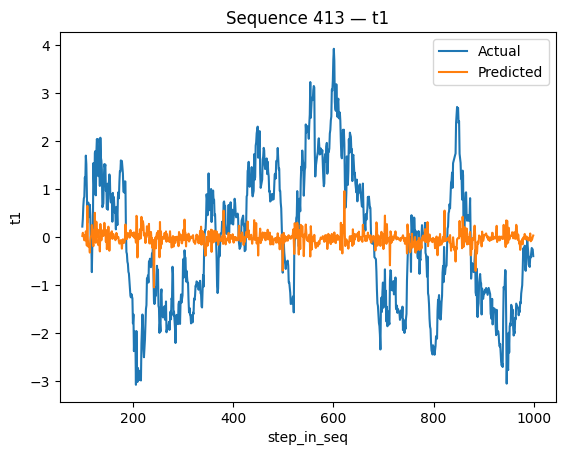

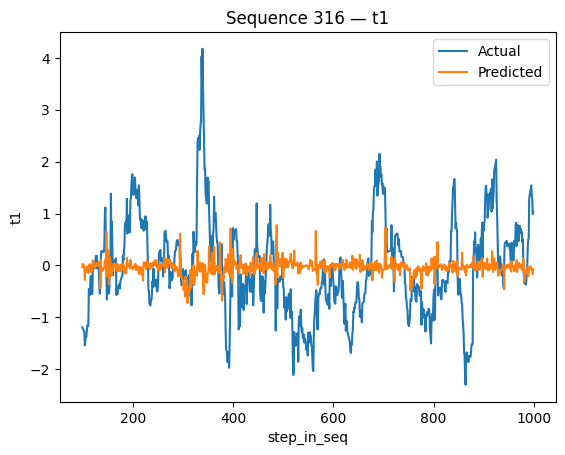

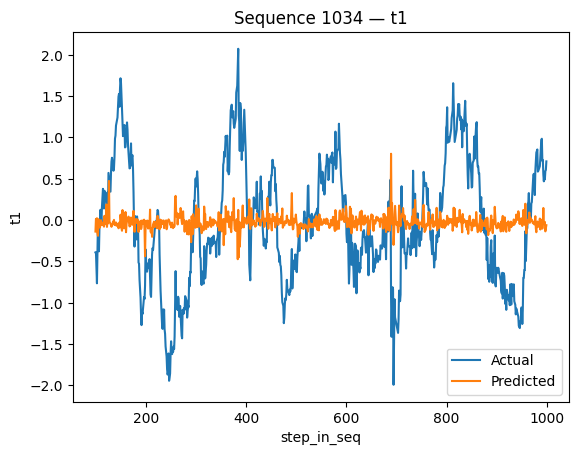

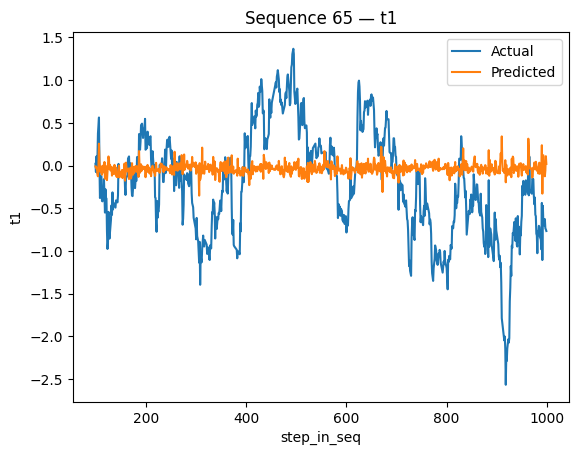

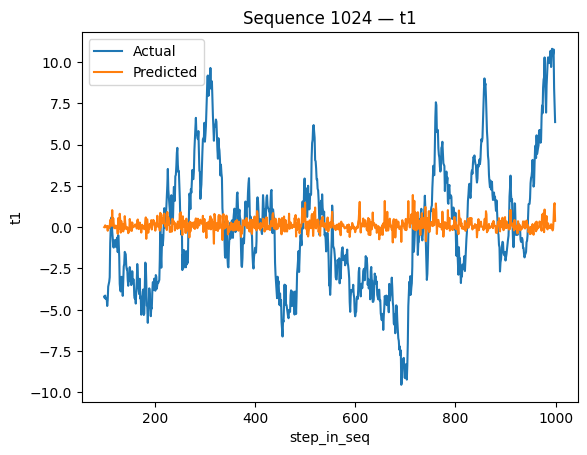

In [ ]:
def plot_sample_sequences(df, target="t0", n_sequences=3, seed=42):
    np.random.seed(seed)

    unique_seqs = df["seq_ix"].unique()
    sampled = np.random.choice(unique_seqs,
                               size=min(n_sequences, len(unique_seqs)),
                               replace=False)

    for seq in sampled:
        seq_df = df[df["seq_ix"] == seq].sort_values("step_in_seq")

        plt.figure()
        plt.plot(seq_df["step_in_seq"],
                 seq_df[target],
                 label="Actual")

        plt.plot(seq_df["step_in_seq"],
                 seq_df[f"pred_{target}"],
                 label="Predicted")

        plt.title(f"Sequence {seq} — {target}")
        plt.xlabel("step_in_seq")
        plt.ylabel(target)
        plt.legend()
        plt.show()


valid_eval = test[test["step_in_seq"] >= 99].copy()
valid_eval["pred_t0"] = pred_t0
valid_eval["pred_t1"] = pred_t1
plot_sample_sequences(valid_eval, target="t0", n_sequences=5)
plot_sample_sequences(valid_eval, target="t1", n_sequences=5)


### TF

In [ ]:
# def normalize_per_sequence(df):
#     feature_means = df.groupby("seq_ix")[feature_cols].transform("mean")
#     feature_stds = df.groupby("seq_ix")[feature_cols].transform("std") + 1e-6
#     df[feature_cols] = (df[feature_cols] - feature_means) / feature_stds
#     return df

# train = normalize_per_sequence(train)
# valid = normalize_per_sequence(valid)

In [9]:
def window_generator(df, window_size=100):
    grouped = df.groupby("seq_ix")

    for seq_ix, seq_df in grouped:
        seq_df = seq_df.sort_values("step_in_seq")

        features = seq_df[feature_cols].values.astype("float32")
        targets = seq_df[["t0", "t1"]].values.astype("float32")
        need_pred = seq_df["need_prediction"].values

        # ✅ normalize per sequence HERE (small array only)
        mean = features.mean(axis=0)
        std = features.std(axis=0) + 1e-6
        features = (features - mean) / std

        for i in range(window_size - 1, len(seq_df)):
            if not need_pred[i]:
                continue

            X = features[i - window_size + 1:i + 1]
            y = targets[i]

            yield X, y

In [10]:
window_size = 100
batch_size = 64

output_signature = (
    tf.TensorSpec(shape=(window_size, len(feature_cols)), dtype=tf.float32),
    tf.TensorSpec(shape=(2,), dtype=tf.float32),
)

train_ds = tf.data.Dataset.from_generator(
    lambda: window_generator(train, window_size),
    output_signature=output_signature
)

valid_ds = tf.data.Dataset.from_generator(
    lambda: window_generator(valid, window_size),
    output_signature=output_signature
)

train_ds = train_ds.shuffle(5000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
valid_ds = valid_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [11]:
def weighted_pearson_tf(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, -6.0, 6.0)
    weights = tf.abs(y_true)

    mean_true = tf.reduce_sum(weights * y_true) / tf.reduce_sum(weights)
    mean_pred = tf.reduce_sum(weights * y_pred) / tf.reduce_sum(weights)

    cov = tf.reduce_sum(weights * (y_true - mean_true) * (y_pred - mean_pred))
    var_true = tf.reduce_sum(weights * tf.square(y_true - mean_true))
    var_pred = tf.reduce_sum(weights * tf.square(y_pred - mean_pred))

    return cov / tf.sqrt(var_true * var_pred + 1e-12)

In [12]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.GRU(64, input_shape=(window_size, len(feature_cols))),
    layers.Dense(32, activation="relu"),
    layers.Dense(2, dtype="float32")
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[weighted_pearson_tf]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,962 (81.88 KB)

 Trainable params: 20,962 (81.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_weighted_pearson_tf",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_weighted_pearson_tf",
    mode="max",
    save_best_only=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_weighted_pearson_tf",
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=100,
    callbacks=[early_stop, checkpoint, lr_scheduler]
)

Epoch 1/100
  30247/Unknown 3344s 110ms/step - loss: 0.7939 - weighted_pearson_tf: 0.4892

In [ ]:
window_size = 100

all_results = []

for seq_ix, seq_df in valid.groupby("seq_ix"):

    seq_df = seq_df.sort_values("step_in_seq").copy()

    features = seq_df[feature_cols].values
    targets = seq_df[["t0", "t1"]].values

    preds_seq = []
    rows_seq = []

    for i in range(window_size - 1, len(seq_df)):

        X_window = features[i - window_size + 1 : i + 1]
        X_window = np.expand_dims(X_window, axis=0)

        y_pred = model.predict(X_window, verbose=0)[0]

        preds_seq.append(y_pred)
        rows_seq.append(seq_df.iloc[i])

    if len(preds_seq) > 0:
        seq_out = pd.DataFrame(rows_seq)
        preds_seq = np.array(preds_seq)

        seq_out["pred_t0"] = preds_seq[:, 0]
        seq_out["pred_t1"] = preds_seq[:, 1]

        all_results.append(seq_out)

# Combine everything
valid_eval = pd.concat(all_results).reset_index(drop=True)

print("Final shape:", valid_eval.shape)

In [ ]:
def plot_sample_sequences(df, target="t0", n_sequences=3, seed=42):
    np.random.seed(seed)

    unique_seqs = df["seq_ix"].unique()
    sampled = np.random.choice(unique_seqs,
                               size=min(n_sequences, len(unique_seqs)),
                               replace=False)

    for seq in sampled:
        seq_df = df[df["seq_ix"] == seq].sort_values("step_in_seq")

        plt.figure()
        plt.plot(seq_df["step_in_seq"],
                 seq_df[target],
                 label="Actual")

        plt.plot(seq_df["step_in_seq"],
                 seq_df[f"pred_{target}"],
                 label="Predicted")

        plt.title(f"Sequence {seq} — {target}")
        plt.xlabel("step_in_seq")
        plt.ylabel(target)
        plt.legend()
        plt.show()

plot_sample_sequences(valid_eval, target="t0", n_sequences=5)
plot_sample_sequences(valid_eval, target="t1", n_sequences=5)

In [ ]:
def weighted_pearson(y_true, y_pred):
    y_pred = np.clip(y_pred, -6, 6)
    weights = np.abs(y_true)

    mean_true = np.sum(weights * y_true) / np.sum(weights)
    mean_pred = np.sum(weights * y_pred) / np.sum(weights)

    cov = np.sum(weights * (y_true - mean_true) * (y_pred - mean_pred))
    var_true = np.sum(weights * (y_true - mean_true)**2)
    var_pred = np.sum(weights * (y_pred - mean_pred)**2)

    return cov / np.sqrt(var_true * var_pred + 1e-12)

y0_valid = valid_eval["t0"].values
y1_valid = valid_eval["t1"].values
pred_t0_arr = valid_eval["pred_t0"].values
pred_t1_arr = valid_eval["pred_t1"].values

score_t0 = weighted_pearson(y0_valid, pred_t0_arr)
score_t1 = weighted_pearson(y1_valid, pred_t1_arr)
final_score = (score_t0 + score_t1) / 2

print("Validation t0:", score_t0)
print("Validation t1:", score_t1)
print("Final Score:", final_score)

## Submission

In [ ]:
import tf2onnx

spec = (tf.TensorSpec((None, window_size, len(feature_cols)), tf.float32),)

model_proto, _ = tf2onnx.convert.from_keras(
    model,
    input_signature=spec
)

with open("my_model.onnx", "wb") as f:
    f.write(model_proto.SerializeToString())

In [ ]:
import os
import sys
import numpy as np

# Adjust path to import utils from parent directory
CURRENT_DIR = os.path.dirname(os.path.abspath(__file__))
sys.path.append(f"{CURRENT_DIR}/..")

from utils import DataPoint, ScorerStepByStep
import onnxruntime as ort

class PredictionModel:
    """
    Baseline Solution (Vanilla GRU).

    This solution uses a simple GRU model trained on 32 features
    to predict t0 and t1.

    Note: This code was generated by an LLM as a baseline demonstration.
    """

    def __init__(self, model_path=""):
        self.current_seq_ix = None
        self.sequence_history = []

        # Determine paths
        base_dir = os.path.dirname(os.path.abspath(__file__))
        onnx_path = os.path.join(base_dir, "baseline.onnx")

        # Initialize ONNX Runtime Session
        sess_options = ort.SessionOptions()
        sess_options.intra_op_num_threads = 1
        sess_options.inter_op_num_threads = 1
        sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

        self.ort_session = None

        try:
            # Load ONNX Model
            self.ort_session = ort.InferenceSession(onnx_path, sess_options, providers=['CPUExecutionProvider'])
            self.input_name = self.ort_session.get_inputs()[0].name
            self.output_name = self.ort_session.get_outputs()[0].name
            print(f"Loaded ONNX model from {onnx_path}")

        except Exception as e:
            print(f"Error loading model resources: {e}")
            self.ort_session = None

    def predict(self, data_point: DataPoint) -> np.ndarray:
        # Reset state on new sequence
        if self.current_seq_ix != data_point.seq_ix:
            self.current_seq_ix = data_point.seq_ix
            self.sequence_history = []

        # Update history
        self.sequence_history.append(data_point.state.copy())

        # If prediction not needed yet, return None
        if not data_point.need_prediction:
            return None

        if self.ort_session is None:
            return np.zeros(2)

        # Prepare input window (last 100 steps)
        # The model was trained with a context window of 100
        history_window = self.sequence_history[-100:]

        # Pad with zeros if history is shorter than 100 (should not happen for need_prediction=True starting at step 99)
        if len(history_window) < 100:
             padding = [np.zeros_like(history_window[0])] * (100 - len(history_window))
             history_window = padding + history_window

        data_arr = np.asarray(history_window, dtype=np.float32)

        # Add batch dimension: (1, Sequence_Length, Features)
        data_tensor = np.expand_dims(data_arr, axis=0)

        # Run inference
        ort_inputs = {self.input_name: data_tensor}
        # Output shape from our VanillaLSTM is (1, 2) because we select the last step inside the model
        output = self.ort_session.run([self.output_name], ort_inputs)[0]

        if len(output.shape) == 3:
            # If model returns (Batch, Seq, Features)
            prediction = output[0, -1, :]
        else:
            # If model returns (Batch, Features)
            prediction = output[0]

        return prediction


if __name__ == "__main__":
    # Local testing
    test_file = f"{CURRENT_DIR}/../datasets/valid.parquet"

    if os.path.exists(test_file):
        model = PredictionModel()
        scorer = ScorerStepByStep(test_file)

        print("Testing Vanilla GRU Baseline (ONNX)...")
        results = scorer.score(model)

        print("\nResults:")
        print(f"Mean Weighted Pearson correlation: {results['weighted_pearson']:.6f}")
        for i, target in enumerate(scorer.targets):
            print(f"  {target}: {results[target]:.6f}")
    else:
        print("Valid parquet not found for testing.")


## Save to Github

In [ ]:
!git config --global user.email "abishpius@gmail.com"
!git config --global user.name "Abish Pius"

In [ ]:
from google.colab import userdata
import requests

token = userdata.get('github')
repo_name = "wonderfund-quant-forecasting"
username = "abishpius"
message = "WunderFund Quant Forecasting Challenge"
notebook_name = "WunderFundForecasting_Challenge.ipynb"

headers = {
    "Authorization": f"token {token}",
    "Accept": "application/vnd.github+json"
}

# === CHECK IF REPO EXISTS ===
check_url = f"https://api.github.com/repos/{username}/{repo_name}"
check_resp = requests.get(check_url, headers=headers)

if check_resp.status_code == 200:
    print(f"❌ Repo '{repo_name}' already exists at: https://github.com/{username}/{repo_name}")
else:
    # === CREATE REPO ===
    create_url = "https://api.github.com/user/repos"
    payload = {
        "name": repo_name,
        "auto_init": True,
        "private": False  # change to True if you want a private repo
    }

    create_resp = requests.post(create_url, headers=headers, json=payload)

    if create_resp.status_code == 201:
        print(f"✅ Repo '{repo_name}' created successfully.")

        # === UPDATE README.md ===
        import base64

        update_url = f"https://api.github.com/repos/{username}/{repo_name}/contents/README.md"
        readme_text = message
        encoded = base64.b64encode(readme_text.encode()).decode()
        update_payload = {
            "message": message,
            "content": encoded,
            "sha": requests.get(update_url, headers=headers).json()["sha"]
        }

        update_resp = requests.put(update_url, headers=headers, json=update_payload)

        if update_resp.status_code == 200 or update_resp.status_code == 201:
            print("✅ README.md updated with custom text.")
        else:
            print("⚠️ Failed to update README.md:", update_resp.json())

    else:
        print("❌ Repo creation failed:", create_resp.json())

In [ ]:
!git clone https://{token}@github.com/{username}/{repo_name}.git

# === MOVE NOTEBOOK ===
import shutil
shutil.copy(f"/content/drive/MyDrive/Colab Notebooks/{notebook_name}", f"/content/{repo_name}/{notebook_name}")

# === COMMIT TO REPO ===
%cd {repo_name}
!git add {notebook_name}
!git commit -m "Added TF GRU Baseline model"
!git push